**Loading Datasets**

In [ ]:
# install SELFIES python package
!pip install -q selfies

In [ ]:
# import required modules
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf

In [ ]:
# mount the drive
drive.mount('/content/drive')
model2_dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Github_Upload/Model_2/"

# import the SELFIES alphabet
model2_SELFIES_alphabet = np.load(model2_dir + 'model2_SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(model1_dir + "model2_target_task_dataset.csv", newline='') as file:
    model2_target_task_dataset = pd.read_csv(file)

Mounted at /content/drive


**One-Hot Encoding of Molecular Physical Structure**

In [ ]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=model2_SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range(0,len(model2_target_task_dataset.index)):
  model2_target_task_dataset['ion1'][i] = OneHot(model2_target_task_dataset.iloc[i][1]) + OneHot(model2_target_task_dataset.iloc[i][2])

del model2_target_task_dataset['ion2']
model2_target_task_dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-4-094fbdd47190>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_dataset['ion1'][i] = OneHot(model2_dataset.iloc[i][1]) + OneHot(model2_dataset.iloc[i][2])


**Append Normalized Temperature as Input**

In [ ]:
# normalize temperature
# for temperature: min = 286.907, range = 46.09300000000002
for i in range(0,len(model2_target_task_dataset.index)):
  model2_target_task_dataset["temperature"][i] = (float(model2_target_task_dataset["temperature"][i]) - 286.907)/46.09300000000002

<ipython-input-5-30a89b10bcba>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_dataset["temperature"][i] = (float(model2_dataset["temperature"][i]) - 286.907)/46.09300000000002


In [ ]:
# append temperature to one-hot encoded molecular structure
for i in range (0,len(model2_target_task_dataset.index)):
  model2_target_task_dataset['ions'][i] = np.concatenate((np.array(model2_target_task_dataset['ions'][i]).reshape(7904,), np.array([model2_target_task_dataset['temperature'][i]])))

<ipython-input-6-bb10cadc8ea1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model2_dataset['ions'][i] = np.concatenate((np.array(model2_dataset['ions'][i]).reshape(7904,), np.array([model2_dataset['temperature'][i]])))


**Machine Learning Algorithm Setup**

In [ ]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out '}

In [ ]:
from transfer_learning import NeuralNet
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def transfer_learning(transfer=False, nsamples=None, nbatches=None, learning_rate=None, num_epochs=None):
    seeds = np.arange(nbatches)
    Ns = list() 
    scores_test = list()
    scores_train = list()

    for seed in tqdm(seeds):
        data_small = model2_target_task_dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0,len(data_small.index)):
          X_small.append(data_small['ions'][i])
          y_small.append(data_small['RI'][i])
        for i in range(0,len(X_small)):
          X_small[i] = np.array(X_small[i]).reshape(7905,).astype(np.float32)
          y_small[i] = y_small[i].astype(np.float32)
        
        X_small = np.array(X_small)
        y_small = np.array(y_small)
        
        PC_small = []
        for i in range (1, 51):
          PC_small.append('PC'+str(i))
        pca = PCA(n_components = 50)
        pca.fit(X_small)
        data_small_pca = pca.transform(X_small)
        df_small_PCA = pd.DataFrame(data_small_pca,columns=PC_small)
        X_small_PCA = df_small_PCA.to_numpy()
        X_small = np.array(X_small_PCA)
        
    
        input_size = 50
        hidden_size_1 = 30
        hidden_size_2 = 15
        output_size = 1

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
        
        if transfer:
            model.load_state_dict(torch.load('/content/drive/MyDrive/Colab_Notebooks/IL_Manuscript/Colab_Model_Import/density_50_PCA_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        scores_epoch = list()
        N = 0
        train_losses = []

        for epoch in range(num_epochs):
            inputs_tl = torch.from_numpy(X_small_train)
            labels_tl = torch.from_numpy(y_small_train)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss = 0
            running_loss += loss.item()
            train_losses.append(running_loss/len(X_small_train))
            
            N += 1
   
        plt.ylim(0,0.000001)
        plt.plot(train_losses, label='Training Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        plt.savefig('/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Figures/SI/TL_Loss_Curves/Model2_TL.png',dpi=600)
        Ns.append(N)

        score_train = mean_absolute_percentage_error(torch.from_numpy(y_small_train).data.numpy(), model(torch.from_numpy(X_small_train)).view(-1,).data.numpy())     
        scores_train.append(score_train)
        score_test = mean_absolute_percentage_error(torch.from_numpy(y_small_test).data.numpy(), model(torch.from_numpy(X_small_test)).view(-1,).data.numpy())
        scores_test.append(score_test)
    
    return scores_train, scores_test

In [ ]:
def Average(score):
    return (sum(score)/len(score))*100

**Direct Learning**

100%|██████████| 100/100 [05:53<00:00,  3.54s/it]


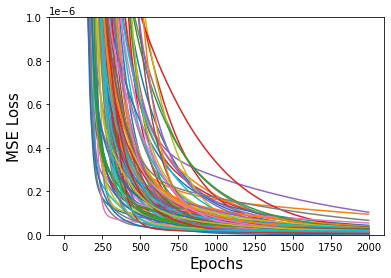

In [ ]:
scores_train_wo_transfer, scores_test_wo_transfer = transfer_learning(transfer=False, nsamples=50, nbatches=100, learning_rate = 0.001, num_epochs = 2000)

In [ ]:
print('The average MAPE of direct learning training set is:', Average(scores_train_wo_transfer),'%')
print('The average MAPE of direct learning testing set is:', Average(scores_test_wo_transfer),'%')

The average MAPE of direct learning training set is: 0.0366999110483448 %
The average MAPE of direct learning testing set is: 3.851592952967622 %


**Transfer Learning**

100%|██████████| 100/100 [23:04<00:00, 13.85s/it]


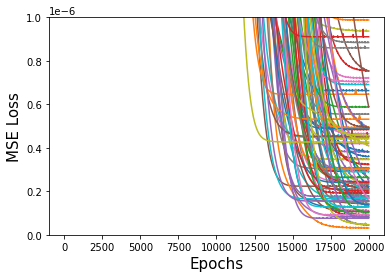

In [ ]:
scores_train_w_transfer, scores_test_w_transfer = transfer_learning(transfer=True, nsamples=50, nbatches=100, learning_rate = 0.0005, num_epochs = 20000)

In [ ]:
print('The average MAPE of transfer learning training set is:', Average(scores_train_w_transfer),'%')
print('The average MAPE of transfer learning testing set is:', Average(scores_test_w_transfer),'%')

The average MAPE of transfer learning training set is: 0.19025957852136344 %
The average MAPE of transfer learning testing set is: 0.9919401737279258 %
